<a href="https://colab.research.google.com/github/Manvi190502/ml/blob/main/Autoencoders_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Dense, Input

In [3]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train.shape

(60000, 28, 28)

In [5]:
X_test.shape

(10000, 28, 28)

In [6]:
X_train=X_train/255.0

In [7]:
X_test = X_test/255.0

In [9]:
X_train=X_train.reshape(len(X_train),28*28)
X_test=X_test.reshape(len(X_test),28*28)

In [10]:
X_train.shape

(60000, 784)

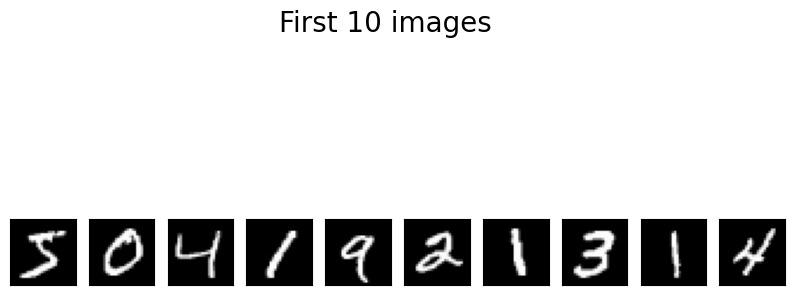

In [15]:
plt.figure(figsize=(10,5))
for i in range(10):
  ax=plt.subplot(1,10,i+1)
  plt.imshow(X_train[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.suptitle('First 10 images',fontsize=20)
plt.show()

In [16]:
def show_visual(data,title,n=10,h=28,w=28):
  plt.figure(figsize=(10,5))
  for i in range(n):
    ax=plt.subplot(1,n,i+1)
    plt.imshow(data[i].reshape(h,w))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
  plt.suptitle(title,fontsize=20)
  plt.show()

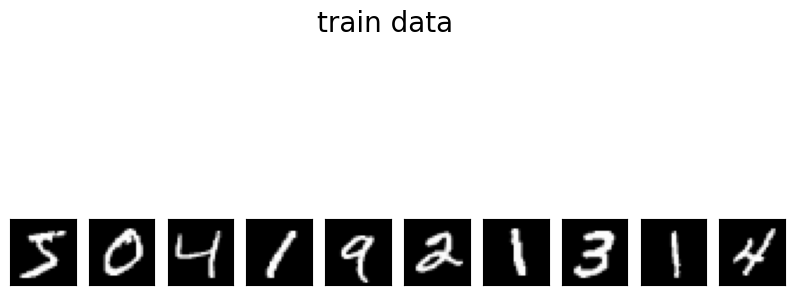

In [18]:
show_visual(X_train,"train data")

In [20]:
input_dim=output_dim=784
encode_dim=100
hidden_dim=256

In [22]:
#encoder
input_layer=Input(shape=(input_dim,),name="INPUT")
hidden_layer_1=Dense(hidden_dim,activation="relu",name="HIDDEN_1")(input_layer)

In [23]:
#bottleneck
bottle_neck=Dense(encode_dim,activation="relu",name="BOTTLENECK")(hidden_layer_1)

In [24]:
#decoder
hidden_layer_2=Dense(hidden_dim,activation="relu",name="HIDDEN_2")(bottle_neck)

In [25]:
#output
output_layer=Dense(output_dim,activation="sigmoid",name="OUTPUT")(hidden_layer_2)

In [26]:
model=Model(input_layer,output_layer)

In [27]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [29]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ INPUT (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HIDDEN_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BOTTLENECK (Dense)              │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HIDDEN_2 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OUTPUT (Dense)                  │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,004 (1.73 MB)

 Trainable params: 454,004 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.fit(X_train,X_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.0120 - loss: 0.1593
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - accuracy: 0.0140 - loss: 0.0826
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.0140 - loss: 0.0772
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.0140 - loss: 0.0744
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.0147 - loss: 0.0728
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.0145 - loss: 0.0718
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.0156 - loss: 0.0709
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.0158 - loss: 0.0705
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - accuracy: 0.0144 - loss: 0.0700
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.0151 - loss: 0.0697


In [31]:
decoded_dta = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [33]:
get_encoded_data=Model(inputs=model.input,outputs=model.get_layer("BOTTLENECK").output)

In [34]:
encoded_data = get_encoded_data.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


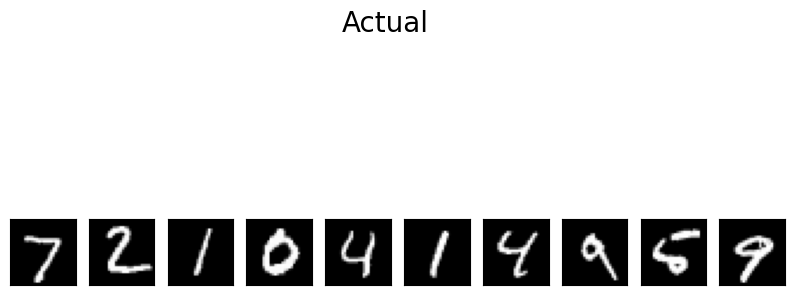

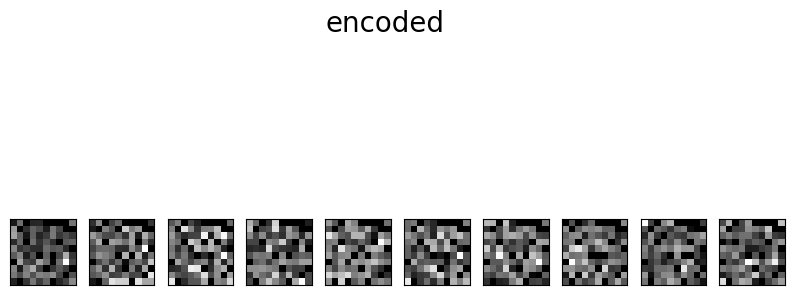

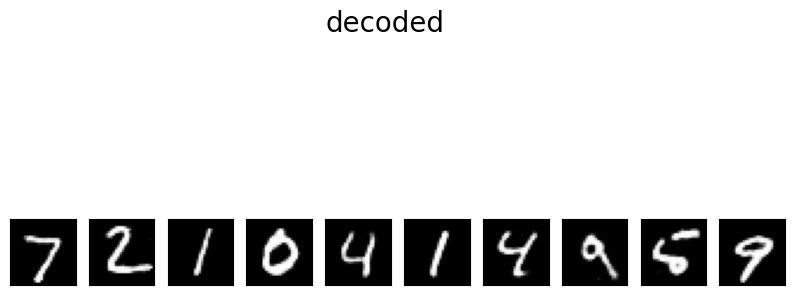

In [36]:
show_visual(X_test,title="Actual")
show_visual(encoded_data,title="encoded",h=10,w=10)
show_visual(decoded_dta,title="decoded")